# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time, get_times, sci_to_latex, plot_LC
import astropy.units as u
import glob
from itertools import cycle
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
def get_energy_from_folder(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [5]:
root = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/*.*" # 30Msun_VdJNL/"
models = sorted(glob.glob(root+"*/"), key=get_energy_from_folder)
print(models)
print(len(models))

['/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d42/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d44/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d46/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d48/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d49/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d50/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/', '/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d51/']
9


In [ ]:
tmax = 72*u.h

/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.0d0/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d42/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d44/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d46/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d48/


...

/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d50/


/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_0.5d51/
/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/bomb_final_e_1.0d51/


Text(0, 0.5, 'radius [cm]')

/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)


/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


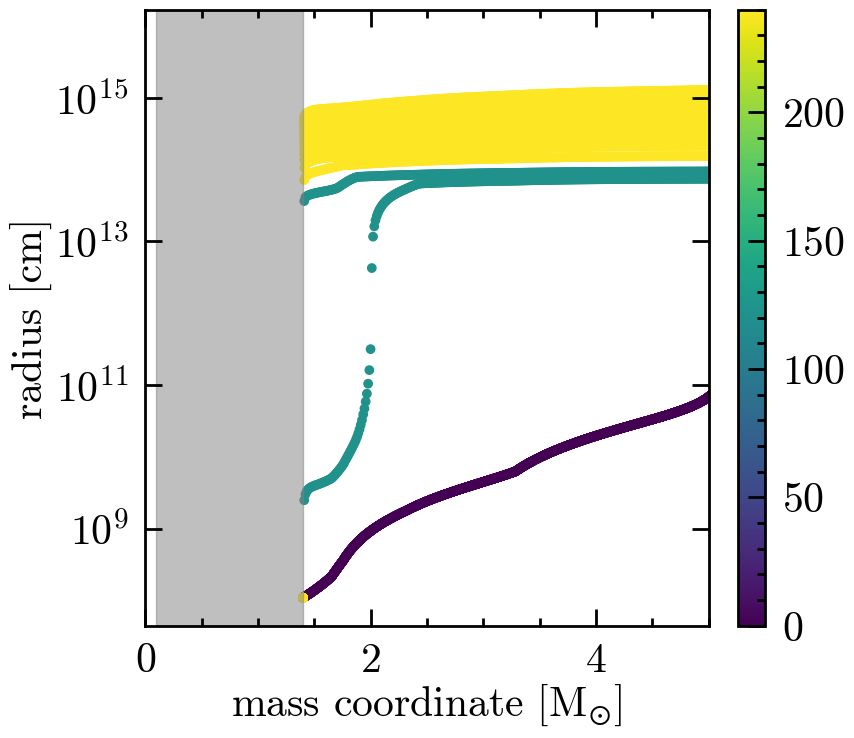

In [6]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
colors = plt.cm.Set2(np.linspace(0,1,len(models)))

for j, m in enumerate(models):
    print(m)
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):
            
            m, r, p = plot_mass_radius(t, outfile, ax=ax, # alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
ax.set_xlim(0, 5.0)
ax.set_yscale('log')
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")

FAILED
FAILED
FAILED


FAILED
FAILED


FAILED
FAILED
FAILED


FAILED
FAILED
FAILED


FAILED
FAILED
FAILED


FAILED
FAILED
FAILED


FAILED


NameError: name 'p' is not defined

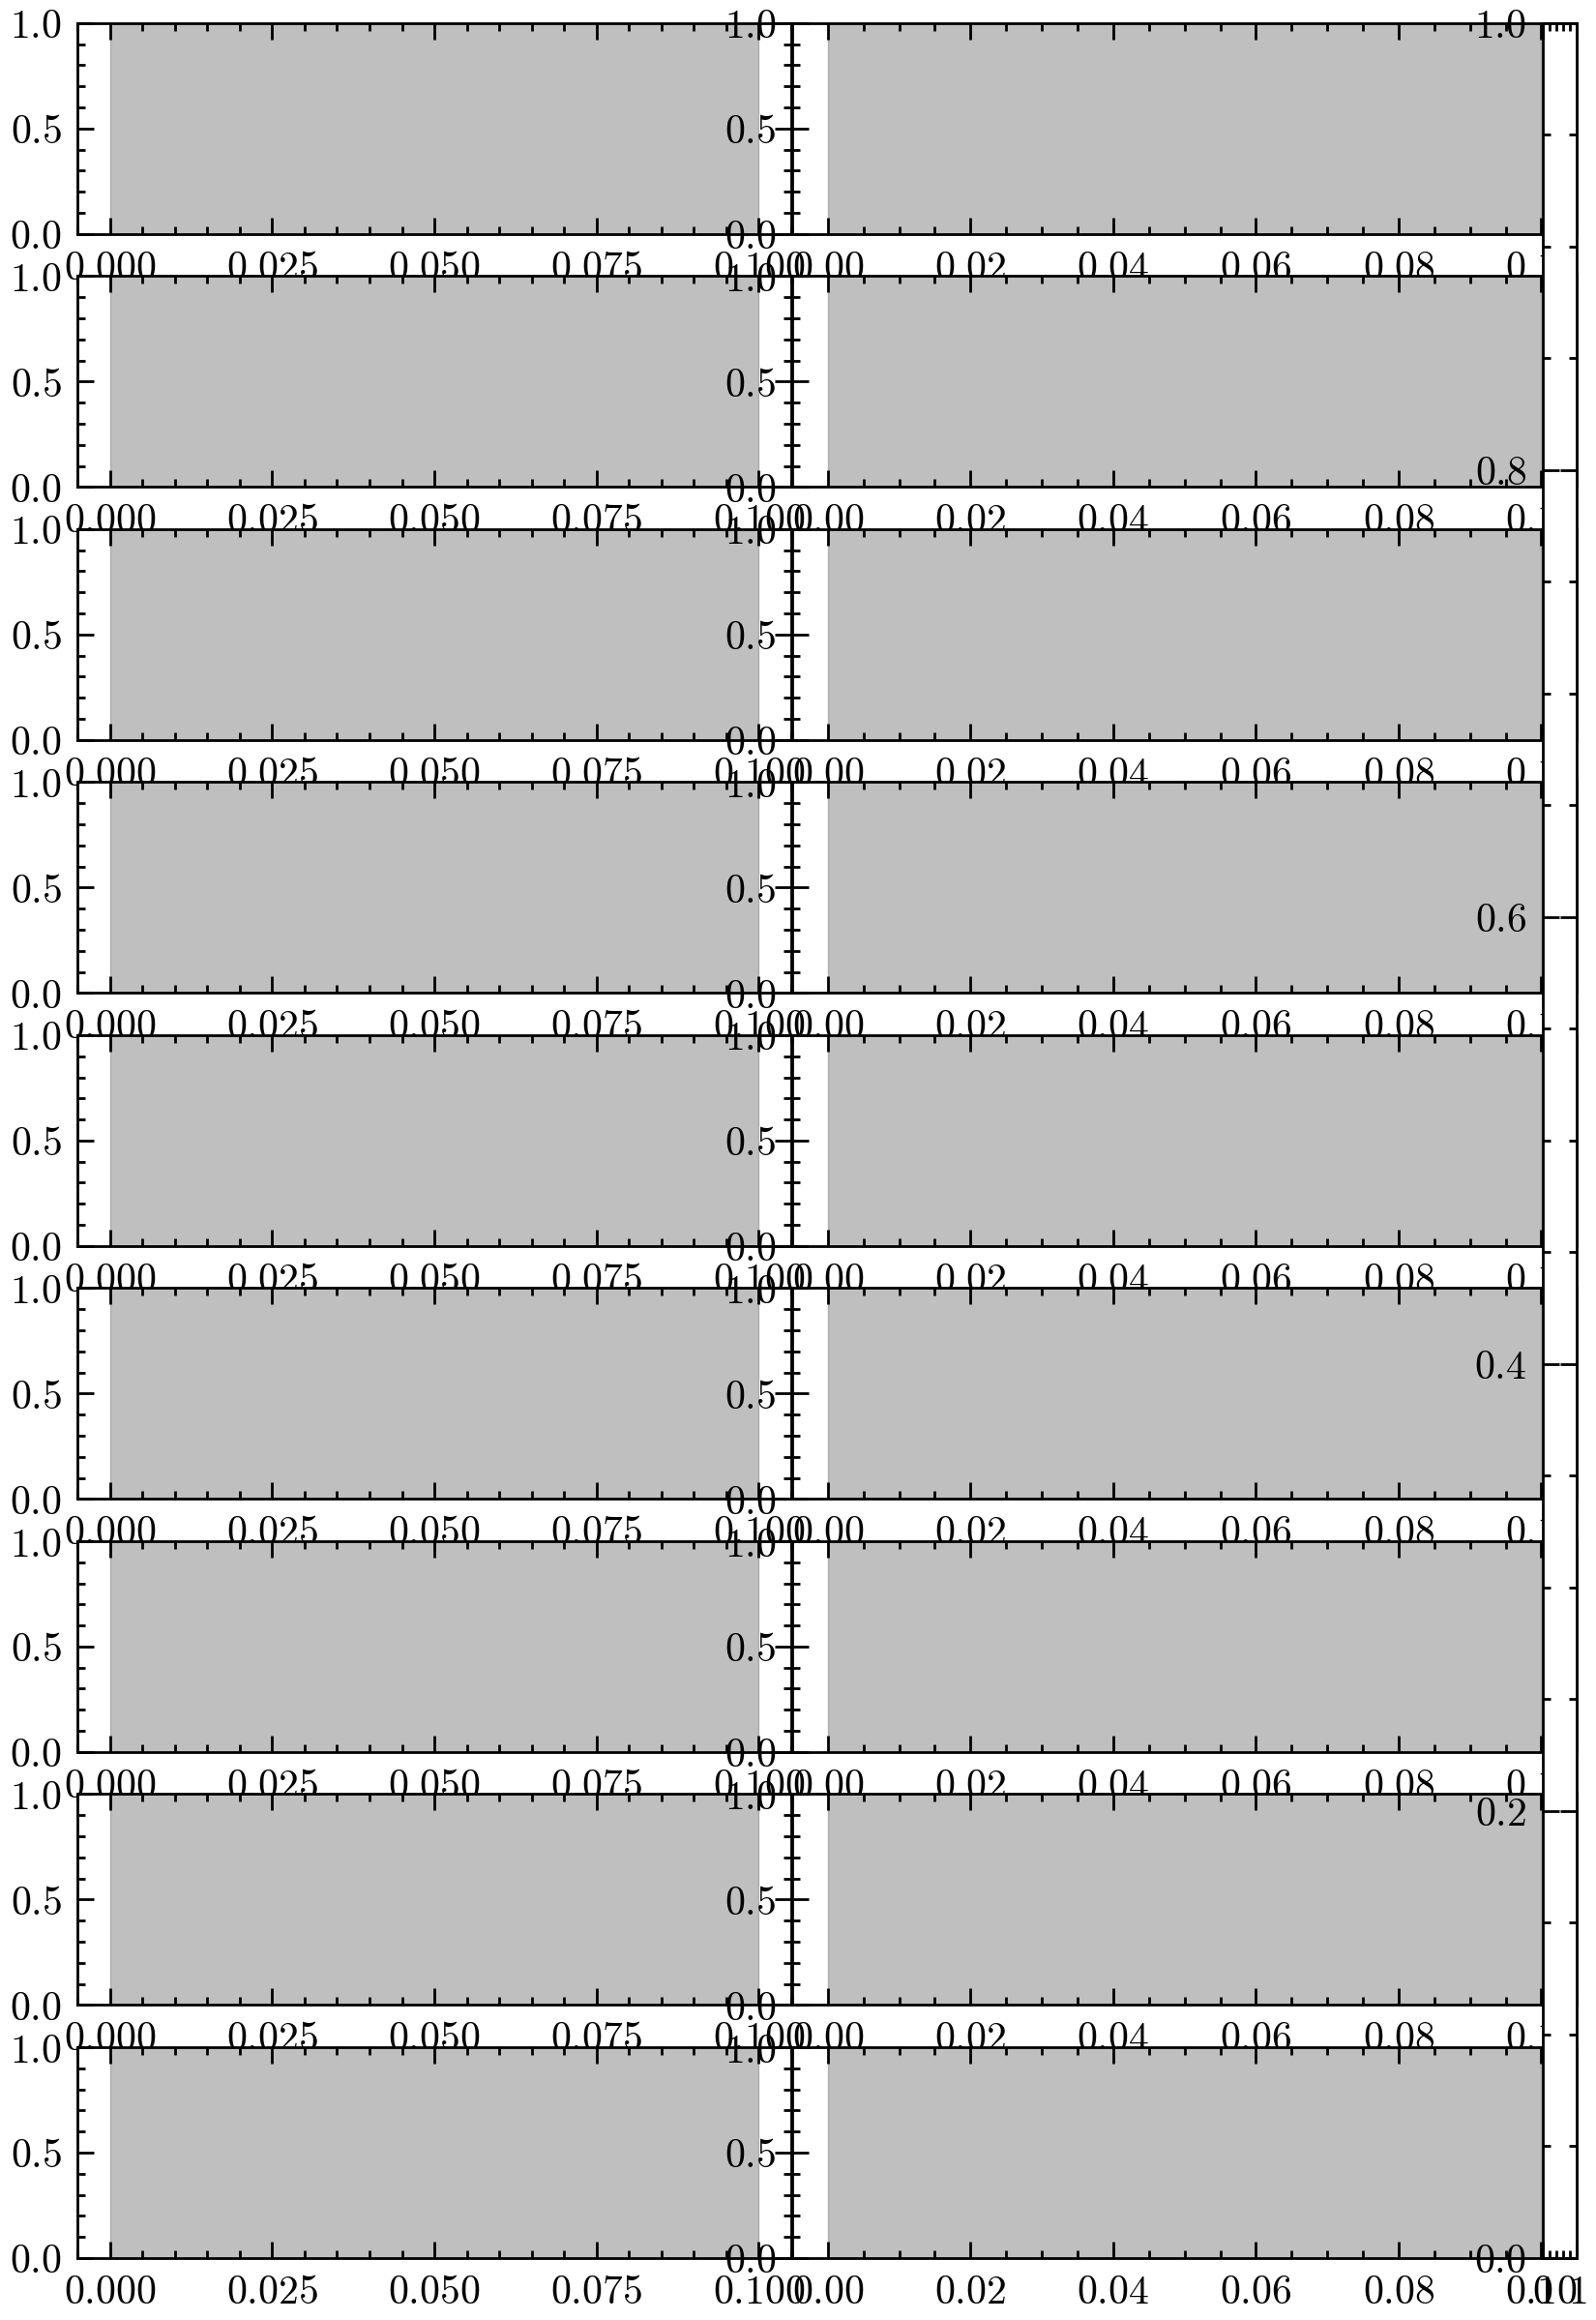

NameError: name 'p' is not defined

In [13]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*.*/"), key=get_energy_from_folder)
# print(len(models15), models15)
for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            xmin = min(m.to(u.Msun))
            print(t.to(u.h))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
    except:
        print("FAILED")
        pass

s30 = "/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/"
models30 = sorted(glob.glob(s30+"*.*/"), key=get_energy_from_folder)
# print(len(models30), models30)
for j, m in enumerate(models30):
    ax = axes[2*j+1]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        for i, t in enumerate(times):
            xmin = min(m.to(u.Msun))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
    except:
        print("FAILED")
        pass

plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")

for i, ax in enumerate(axes):
    # ax.set_xlim(0, 5.0)
    ax.set_yscale('log')
    if (i%2 !=0): ax.set_yticklabels([])
    if (i != 16) and (i !=17): ax.set_xticklabels([])
    
axes[0].set_title(r"$15M_{\odot}$ RSG", size=30)
axes[1].set_title(r"$30M_{\odot}$ WR", size=30)
axes[16].set_xlabel(r"mass coordinate [$M_{\odot}$]")
axes[17].set_xlabel(r"mass coordinate [$M_{\odot}$]")
cax.set_ylabel(r"time [h]")
# ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
# ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$") 

FAILED
FAILED


FAILED
FAILED


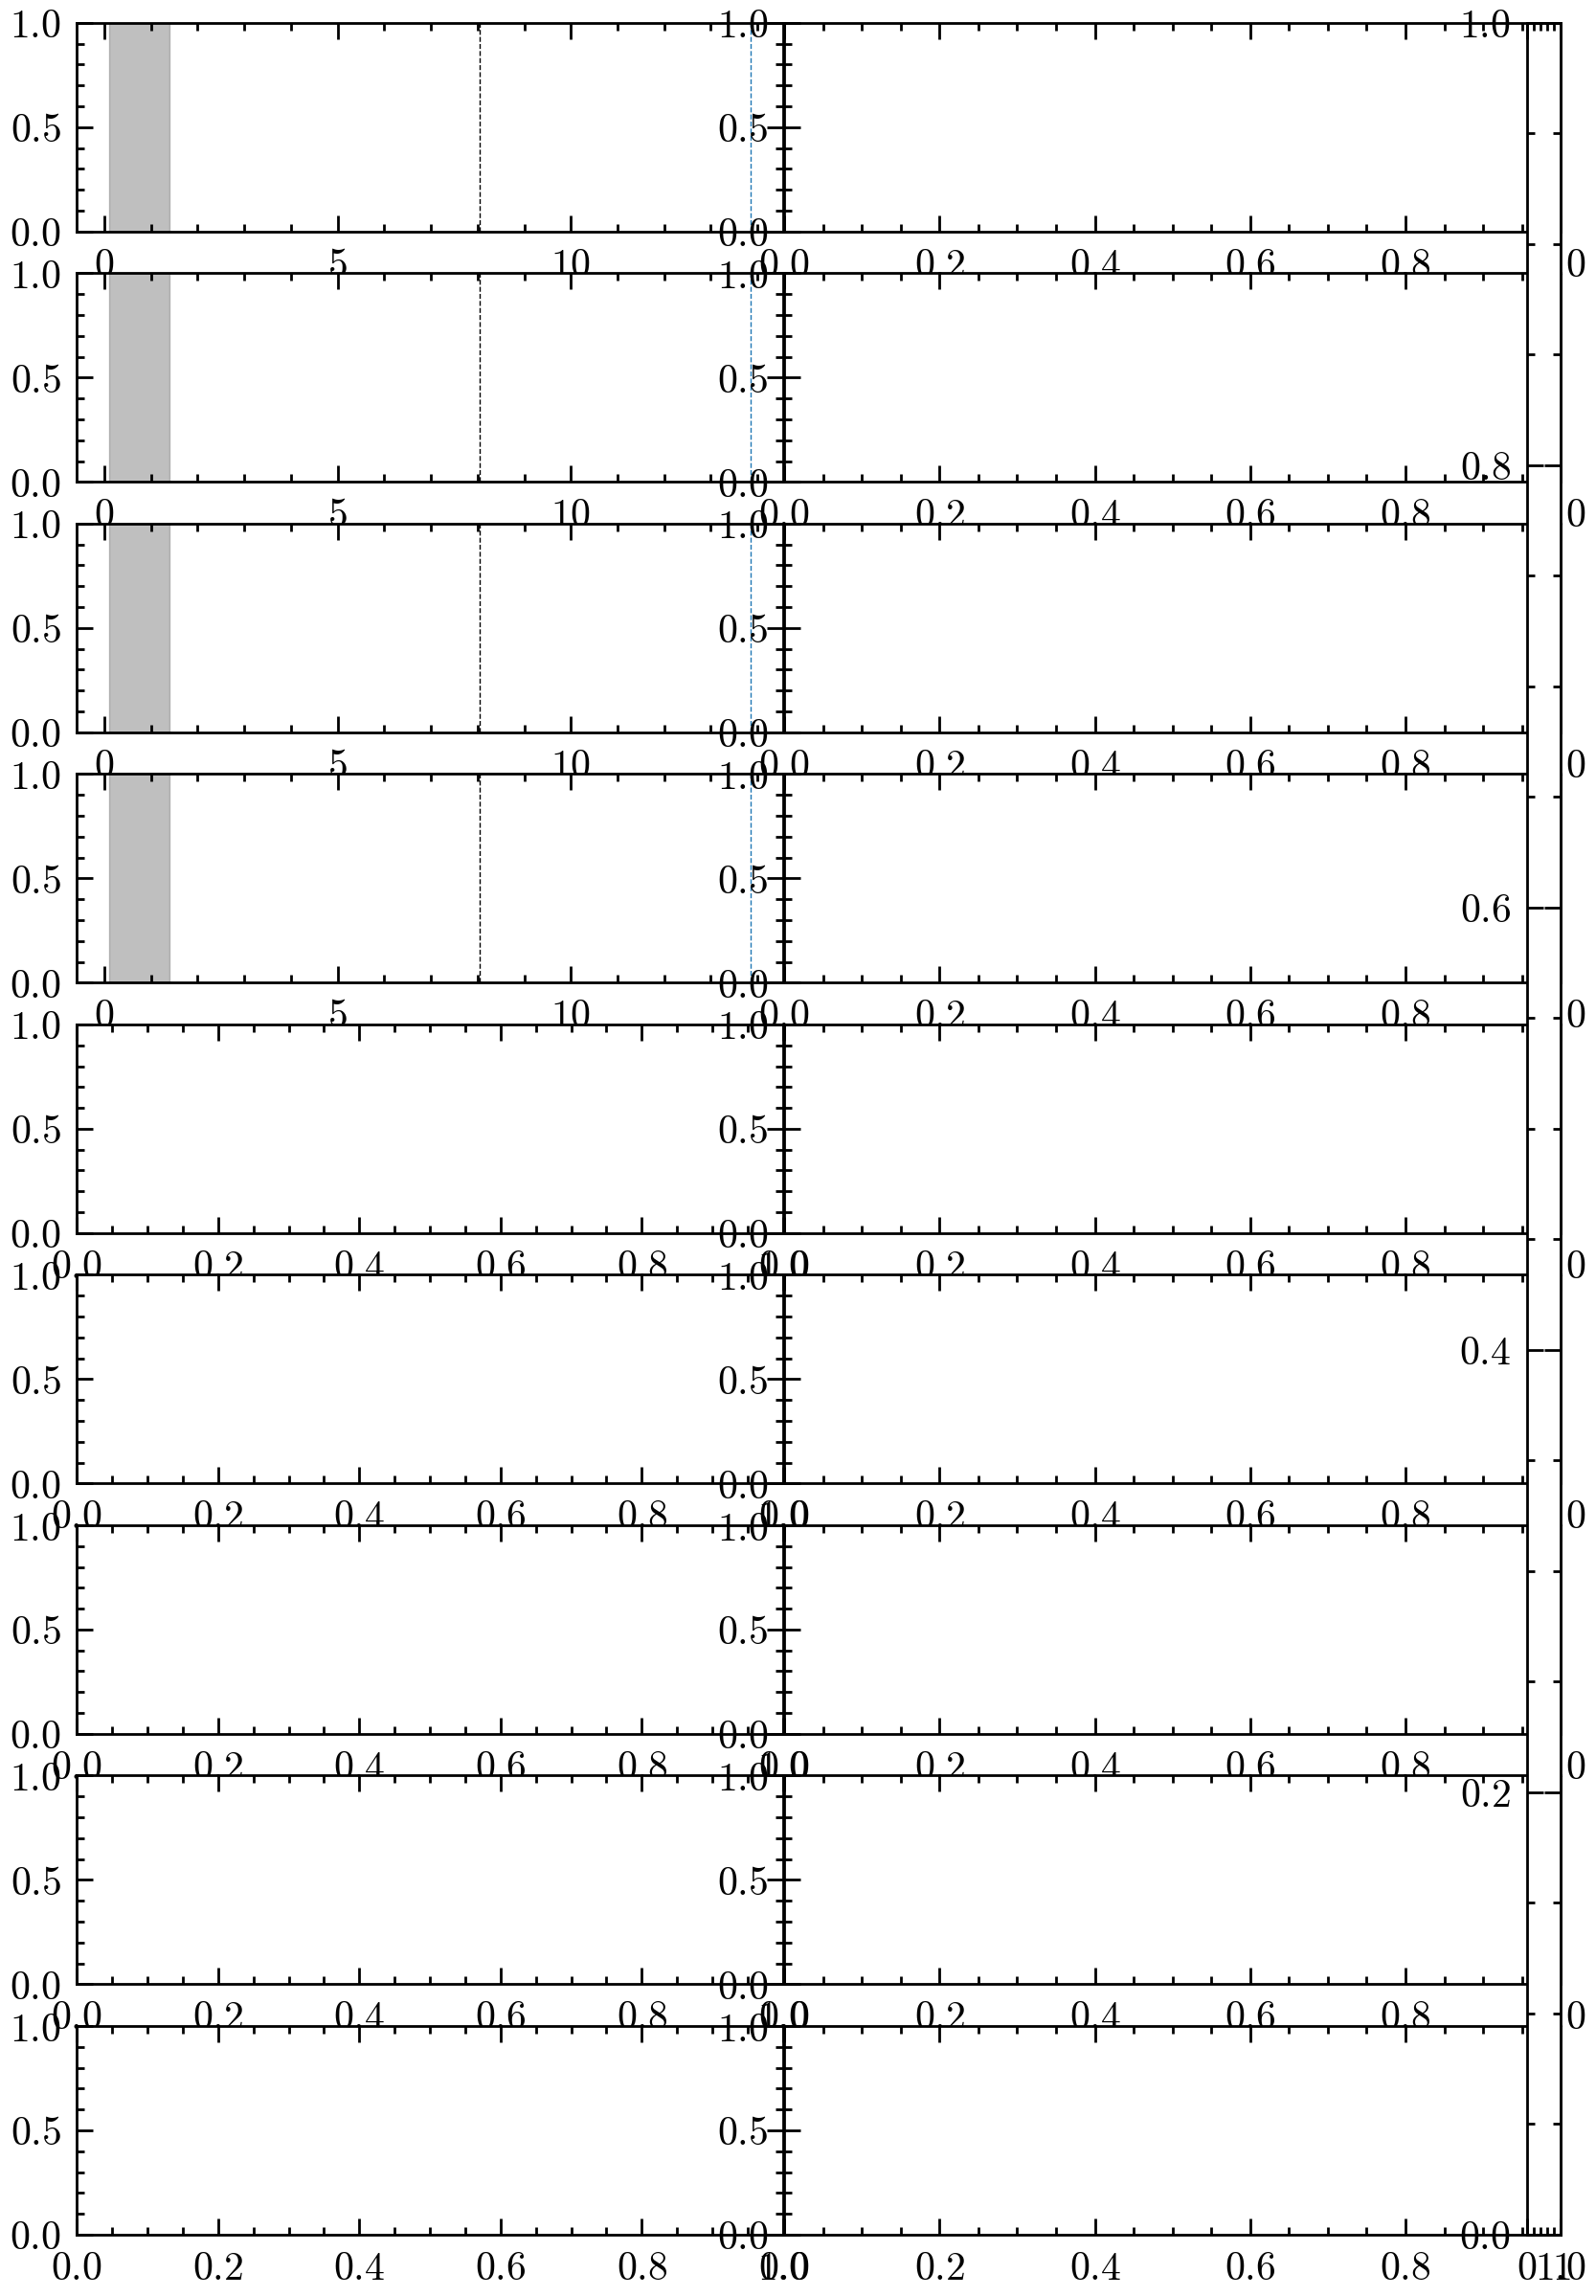

In [15]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*/*.*/"), key=get_energy_from_folder)

for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        vel_file = m+'Data/vel.xg'
        mass_file = m+'Data/mass.xg'
        times = get_times(vel_file)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):           
            m, r, p = plot_v_radius_time(t, vel_file, mass_file,
                                         ax=ax, alpha=0.5, # s=10*(1+i),
                                         # c=colors[j],
                                         # ls = linestyles[j],
                                         label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass


/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_0.0d0/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d42/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d44/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d46/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d48/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d49/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d50/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_0.5d51/
/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/bomb_final_e_1.0d51/


/tmp/ipykernel_1318467/1191483159.py:12: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

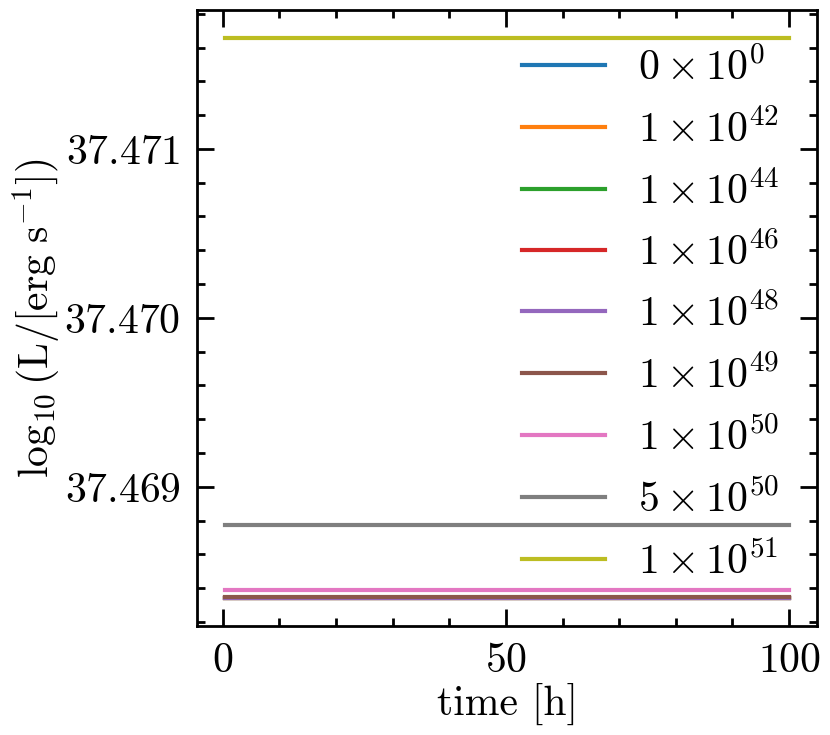

In [9]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for m in models30:
    try:
        plot_LC(m, ax=ax, label=sci_to_latex(get_energy_from_folder(m)))
    except: # IndexError:
        pass
    #    print(m, "failed")
    
ax.legend()
ax.set_xlabel(r"time [h]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")